In [1]:
import numpy as np
import matplotlib.pylab as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.special import ellipk, ellipe
from numpy import vectorize
from contourpy import contour_generator

In [2]:
# Profiles
# n = 0:   NIS
# n = 3:   NFW
# n = 3.5: sNFW
# n = 4:   Hernquist

# Convergence (Simplified)
def Convergence_sim(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = k0/np.sqrt(np.pi)
        if x == 1: 
            return amp/3
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(1/(x**2 - 1))*(1 - np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(1/(x**2 - 1))*(1 - np.arccos(1/x)/arg)
            
    #sNFW
    if n == 3.5:
        arg = (1 - x)/(1 + x)
        if x == 1:
            return k0*9*np.pi/(128*np.sqrt(2))
        if x != 1:
            return k0*(((3 + x)*ellipk(arg) - 4*ellipe(arg))/(2*(1 - x)**2*(1 + x)**(3/2)))
            
        
    #Hernquist
    if n == 4:
        amp = k0/np.sqrt(np.pi)
        if x == 1: 
            return 4*amp/15
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccosh(1/x) - 3)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccos(1/x) - 3)

    #NIS
    if n == 0:
        return k0*np.sqrt(np.pi)/np.sqrt(1 + x**2)


# Deflection angle (Simplified)
def DAngle_sim(x, n, k0):
    """
    x: dimensionless radius (position)
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp*(1 - np.log(2))
        if 0 < np.abs(x) < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/x)*(np.log(0.5*np.abs(x)) + np.arccosh(1/np.abs(x))/arg)
        if np.abs(x) > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/x)*(np.log(0.5*np.abs(x)) + np.arccos(1/np.abs(x))/arg)
    #sNFW
    if n == 3.5:
        amp = 2*k0
        arg = (1 - np.abs(x))/(1 + np.abs(x))
        if x == 0:
            return 0.
        if np.abs(x) == 1:
            return amp*(1 - 3*np.pi/(8*np.sqrt(2)))
        if np.abs(x) > 0 and np.abs(x) != 1:
            return (amp/x)*(((ellipe(arg) - np.abs(x)*ellipk(arg))/(np.sqrt(1 + np.abs(x))*(np.abs(x) - 1))) + 1)
    
    #Hernquist
    if n == 4:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp/3
        if 0 < np.abs(x) < 1:
            arg = np.sqrt(1. - x**2)
            return (amp*x/(x**2 - 1))*(1 - np.arccosh(1/np.abs(x))/arg)
        if np.abs(x) > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp*x/(x**2 - 1))*(1 - np.arccos(1/np.abs(x))/arg)

    #NIS
    if n == 0:
        if x == 0:
            return 0
        else:
            return 2*np.sqrt(np.pi)*k0*(np.sqrt(1 + x**2) - 1)/x

# Vectorized functions
c_sim = vectorize(Convergence_sim, otypes=[float], cache = True)
da_sim = vectorize(DAngle_sim, otypes=[float], cache = True)

In [3]:
# Equation for fincding the radial critical curve: RCC = 0
def RCC(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    return 1 + DAngle_sim(x, n, k0)/x - 2*Convergence_sim(x, n, k0)

# Equation for fincding the tangential critical curve: TCC = 0
def TCC(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    return 1 - DAngle_sim(x, n, k0)/x
    
# Vectorized functions
tcc = vectorize(TCC, otypes=[float], cache = True)
rcc = vectorize(RCC, otypes=[float], cache = True)

In [4]:
def CCSolve(cri, crf, cti, ctf, N, RN, n, k0):
    """
    Here, we follow a similar process to the described in our paper (Sec. 5.2) for solving the lens equation. 
    
    For example, if we want to find the tangential critical curve, we take the domain (cti, ctf) and construct a one-dimensional grid
    with N nodes. Then, we evaluate the function TCC for that grid, such that the node for wich TCC is closest to zero corresponds to
    the tagential critical curve. Here, we can follow a refinement process which we repeat RN times. For RN = 1 we need N to be a
    relatively large number. However, if RN > 1, we can use a smaller N, and considering that the computed critical curve (approximately) 
    is the node x_i, the refinament process take the interval (x_(i-1), x_(i+1)) and construct the new grid, for which we repeat the 
    process. For the radial critical curve we follow the same process.
    
    (cri, crf): limits (they are both positive) within which we consider the critical radial curve is lolated
    (cti, ctf): limits (they are both positive) within which we consider the critical tangental curve is lolated
    N: number of nodes 
    RN: how many times we oerform the refinement
    n: profile
    k0: characteristic convergence
    """
    
    dx1 = np.abs(ctf - cti)/N
    dx2 = np.abs(crf - cri)/N
    x1 = np.linspace(cti, ctf, N)
    x2 = np.linspace(cri, crf, N)
    
    for i in range(RN):
        d1 = np.abs(tcc(x1, n, k0))
        d2 = np.abs(rcc(x2, n, k0))
        ind1 = np.where(d1 == np.amin(d1))[0][0]
        ind2 = np.where(d2 == np.amin(d2))[0][0]
        
        tan = x1[ind1]
        rad = x2[ind2]

        if tan - dx1 < 0:
            x1 = np.linspace(tan, tan + dx1, N)
        else:
            x1 = np.linspace(tan - dx1, tan + dx1, N)
        if rad - dx2 < 0:
            x2 = np.linspace(rad, rad + dx2, N)
        else:
            x2 = np.linspace(rad - dx2, rad + dx2, N)
            
        dx1 = 2*dx1/N
        dx2 = 2*dx2/N

        if np.abs(tcc(tan, n, k0)) <= 1e-15 and np.abs(rcc(rad, n, k0)) <= 1e-15:
            break

    return rad, tan

In [5]:
def LESolve1(y, xi, xf, N, RN, n, k0):
    """
    Given a source with radial position y, this function solves the lens equation considering that only one solution exists, and it is 
    located within the interval (xi, xf). We follow the process described in our paper (Sec. 5.2).

    Within the domain (xi, xf) we construct a one-dimensional grid with N nodes. Then, we evaluate the lens equation for that grid, 
    such that the node for wich x - deflection_angle is closest to be equal to y, is the potential solution to the lens equation. 
    Here, we can follow a refinement process which we repeat RN times. For RN = 1 we need N to be a relatively large number.
    However, if RN > 1, we can use a smaller N, and considering that the computed solution (approximately) is the node x_i, the 
    refinament process take the interval (x_(i-1), x_(i+1)) and construct the new grid, for which we repeat the process.

    y > yc2 (radial caustic curve): source radial position
    (xi, xf): limits (they are both positive) within which we consider the image is lolated. Here, xi >= xb. 
    N: number of nodes 
    RN: how many times we oerform the refinement
    n: profile
    k0: characteristic convergence
    """

    dx = np.abs(xf - xi)/N
    x = np.linspace(xi, xf, N)
    for i in range(RN):
        d = np.abs(y - x + da_sim(x, n, k0))
        ind = np.where(d == np.amin(d))[0][0]

        xb = x[ind]
        
        x = np.linspace(xb - dx, xb + dx, N)
        dx = 2*dx/N
        if np.abs(y - xb + da_sim(xb, n, k0))<= 1e-15 :
            break

    return xb

def LESolve3(y, xc1, xc2, xb, N, RN, n, k0):

    """
    Given a source with radial position 0 < y < yc2, this function solves the lens equation finding the three possible images. These
    images are formed at (-xc1, -xc2), (-xc2, 0), and (xc1, xb). Recall that the minus sign represents the images having azimuthal 
    difference of pi radians with respect to the source. We follow the process described in our paper (Sec. 5.2).

    For example, if we wan to find the image formed within (xc1, xb), we take this domain and construct a one-dimensional grid with N nodes.
    Then, we evaluate the lens equation for that grid, such that the node for wich x - deflection_angle is closest to be equal to y, is 
    the potential solution to the lens equation. Here, we can follow a refinement process which we repeat RN times. For RN = 1 we need N to 
    be a relatively large number. However, if RN > 1, we can use a smaller N, and considering that the computed solution (approximately) is 
    the node x_i, the  refinament process take the interval (x_(i-1), x_(i+1)) and construct the new grid, for which we repeat the process.
    We follow the same process for the other two images.

    0 < y < yc2 (radial caustic curve): source radial position
    xc1 > 0: tangential critical curve
    xc2 > 0: radial critical curve
    xb > 0:  boundary within which multiple images can appear
    N: number of nodes 
    RN: how many times we oerform the refinement
    n: profile
    k0: characteristic convergence
    """
    
    roots = np.zeros(3)
    dx1 = np.abs(xc2)/N
    dx2 = np.abs(xc1 - xc2)/N
    dx3 = np.abs(xb - xc1)/N
    x1 = np.linspace(-xc2, 0, N)
    x2 = np.linspace(-xc1, -xc2, N)
    x3 = np.linspace(xc1, xb, N)
    for i in range(RN):
        d1 = np.abs(y - x1 + da_sim(x1, n, k0))
        d2 = np.abs(y - x2 + da_sim(x2, n, k0))
        d3 = np.abs(y - x3 + da_sim(x3, n, k0))
        ind1 = np.where(d1 == np.amin(d1))[0][0]
        ind2 = np.where(d2 == np.amin(d2))[0][0]
        ind3 = np.where(d3 == np.amin(d3))[0][0]
        r1 = x1[ind1]
        r2 = x2[ind2]
        r3 = x3[ind3]
        x1 = np.linspace(r1 - dx1, r1 + dx1, N)
        x2 = np.linspace(r2 - dx2, r2 + dx2, N)
        x3 = np.linspace(r3 - dx3, r3 + dx3, N)
        dx1 = 2*dx1/N
        dx2 = 2*dx2/N
        dx3 = 2*dx3/N
        
        roots[1] = r1
        roots[0] = r2
        roots[2] = r3

    return roots

In [6]:
"""
Here, we compute the main features needed to describe the lensing effect, particularly ragarding image fomation.

We find the boundaries that rule image formation, such as critial and caustic curves. 
"""

k0 = 3 # Characteristic convergence
n = 3.5 # sNFW

# Critical curves
# xc1: tangential
# xc2: radial
xc2, xc1 = CCSolve(0.1, 2, 0.1, 2, 10, 100, n, k0)
# Here we verify that the critial curves  are correct
print("|RCC| =", np.abs(RCC(xc2, n, k0))) # Ideally, it should be equal to zero 
print("|TCC| =", np.abs(TCC(xc1, n, k0))) # Ideally, it should be equal to zero 

# Caustic curves
# yc1: tangential (have to be zero)
# yc2: radial
yc1 = np.abs(xc1 - da_sim(xc1, n, k0))
yc2 = np.abs(xc2 - da_sim(xc2, n,k0))

# xb: boundary within which multiple images can appear
xb = LESolve1(yc2, xc1, 10, 10, 100, n, k0)
yb = np.abs(xb - da_sim(xb, n, k0))
# xb and xc2 are images of the same source, thus, yb = yc2
print("|yc2 - xb + da(xb)| =", np.abs(yc2 - xb + da_sim(xb, n, k0))) # Ideally, it should be equal to zero

print("********************")

print("xc2 = ", xc2)
print("xc1 = ", xc1)
print("xcb = ", xb)
print("yc1 = ", yc1)
print("yc2 = ", yc2)
print("yb  = ", yb)

|RCC| = 8.881784197001252e-16
|TCC| = 6.561418075534675e-14
|yc2 - xb + da(xb)| = 1.1102230246251565e-16
********************
xc2 =  0.28832541734928757
xc1 =  1.0016497365896522
xcb =  1.4890524787248882
yc1 =  6.572520305780927e-14
yc2 =  0.5407143517096094
yb  =  0.5407143517096092


In [7]:
"""
Here, we compute the different features present in panel (a), such as the lens equation and the different cases of image formation.
"""

# Lens equation
points = 500
xe = np.linspace(0, 5, points)
le = xe - da_sim(xe, n, k0)

x1 = LESolve3(yc2/2, xc1, xc2, xb, 1000, 10, n, k0) # Three images (blue)
y1 = x1 - da_sim(x1, n, k0)
print("y1: ", yc2/2, y1)

x2 = np.array([-xc2, xb]) # Two images (green)
y2 = x2 - da_sim(x2, n, k0)
print("y2: ", yc2, y2)

x3 = LESolve1((1 + yc2)/2, xc1, 10, 1000, 10, n, k0) # One image (orange)
y3 = x3 - da_sim(x3, n, k0)
print("y3: ", (1 + yc2)/2, y3)

y1:  0.2703571758548047 [0.27035718 0.27035718 0.27035718]
y2:  0.5407143517096094 [0.54071435 0.54071435]
y3:  0.7703571758548047 0.7703571758548047


In [8]:
"""
Here, we compute the different features present in panel (b).
"""

xl = 1.8
yl = 1.8

# Domain of interest
xc = np.linspace(-xl, xl, points)
yc = np.linspace(-yl, yl, points)

ang = np.linspace(0,2*np.pi, 1000)

#Caustic radial curve
cax = yc2*np.cos(ang)
cay = yc2*np.sin(ang)
#Critical radial curve
crx = xc2*np.cos(ang)
cry = xc2*np.sin(ang)
#Critical tangential curve
ctx = xc1*np.cos(ang)
cty = xc1*np.sin(ang)

# Extended Surce
R0 = 0.2 # Radius

# Centre (red)
x01 = 0 
y01 = 0

# Centre (blue)
x02 = 0.5*yc2/np.sqrt(2)
y02 = x02

# Centre (gree)
x03 = yc2/np.sqrt(2)
y03 = x03

# Centre (orange)
x04 = 1.5*yc2/np.sqrt(2)
y04 = x04

# Sources
x11 = R0*np.cos(ang) + x01 # red
y11 = R0*np.sin(ang) + y01

x21 = R0*np.cos(ang) + x02 # blue
y21 = R0*np.sin(ang) + y02

x31 = R0*np.cos(ang) + x03 # green
y31 = R0*np.sin(ang) + y03

x41 = R0*np.cos(ang) + x04 # orange
y41 = R0*np.sin(ang) + y04

In [9]:
"""
Here, we establish images for an extended circular source as depicted in panel (b). 

We find the different images from the contours that satisfy the lens equation.
""" 
X, Y = np.meshgrid(xc, yc)
R = np.sqrt(X**2 + Y**2) # Radial coordinate map for all points in the domain

ang = np.arctan2(Y,X) # Algle with respect to the x axis for all points in the domain
dac = da_sim(R, n, k0) # Deflection angle map for all points in the domain

In [10]:
"""
For more details on how to find the images for a circular extended source, see page 298 
of Gravitational Lenses (1992) by Schneider, Ehlers, and falco. 
"""
C1 = np.sqrt((X - dac*np.cos(ang) - x01)**2 + (Y - dac*np.sin(ang) - y01)**2)
C2 = np.sqrt((X - dac*np.cos(ang) - x02)**2 + (Y - dac*np.sin(ang) - y02)**2)
C3 = np.sqrt((X - dac*np.cos(ang) - x03)**2 + (Y - dac*np.sin(ang) - y03)**2)
C4 = np.sqrt((X - dac*np.cos(ang) - x04)**2 + (Y - dac*np.sin(ang) - y04)**2)

In [11]:
"""
Here, for each source we find the contours (i.e., those X, Y) that satisfy C1 = R0 and so on.

For these task we use contourpy instead of matplotlib, because the latest version of matplotlib does not 
provide the contour curves individually.
"""

cc1 = contour_generator(z=C1)
cc2 = contour_generator(z=C2)
cc3 = contour_generator(z=C3)
cc4 = contour_generator(z=C4)

sx1 = []
sy1 = []

sx2 = []
sy2 = []

sx3 = []
sy3 = []

sx4 = []
sy4 = []

for item in cc1.lines(R0):
        sx1.append((item[:,0]/points - 1/2)*2*xl)
        sy1.append((item[:,1]/points - 1/2)*2*xl)
        
for item in cc2.lines(R0):
        sx2.append((item[:,0]/points - 1/2)*2*xl)
        sy2.append((item[:,1]/points - 1/2)*2*xl)

for item in cc3.lines(R0):
        sx3.append((item[:,0]/points - 1/2)*2*xl)
        sy3.append((item[:,1]/points - 1/2)*2*xl)

for item in cc4.lines(R0):
        sx4.append((item[:,0]/points - 1/2)*2*xl)
        sy4.append((item[:,1]/points - 1/2)*2*xl)

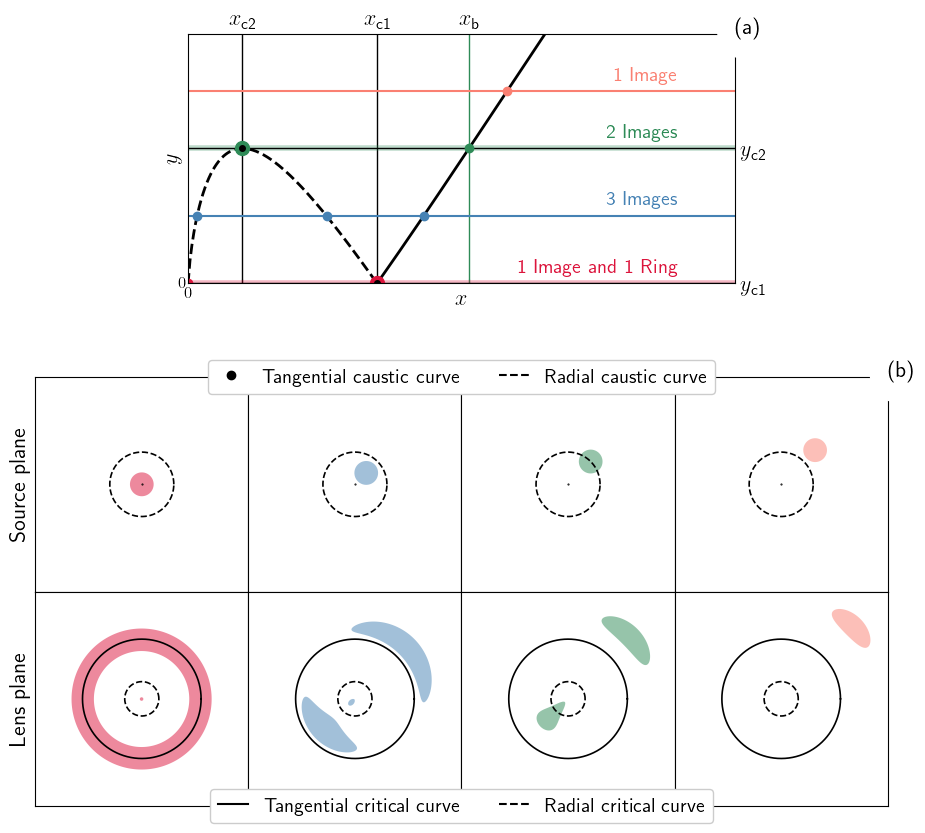

In [12]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{braket}')
plt.rc('text', usetex = True)

fig = plt.figure(figsize = (11,15.6))

gs1 = GridSpec(1, 12, bottom = 0.72, wspace = 5, hspace = 5)
ax0 = fig.add_subplot(gs1[0, 2:-2])

gs2 = GridSpec(4, 4, top = 0.66, hspace = 0, wspace = 0)
ax1 = fig.add_subplot(gs2[0, 0])
ax2 = fig.add_subplot(gs2[0, 1])
ax3 = fig.add_subplot(gs2[0, 2])
ax4 = fig.add_subplot(gs2[0, 3])
ax5 = fig.add_subplot(gs2[1, 0])
ax6 = fig.add_subplot(gs2[1, 1])
ax7 = fig.add_subplot(gs2[1, 2])
ax8 = fig.add_subplot(gs2[1, 3])

axis_fs = 16
ticks_s = 12

lc = 1.2

color0 = "crimson"
color1 = "steelblue"
color2 = "seagreen"
color3 = "salmon"


#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Panel (a) diagram
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax0.vlines(xc2, -10, 10, colors="k", linestyles='-', lw =1)
ax0.vlines(xc1, -10, 10, colors="k", linestyles='-', lw =1)
ax0.vlines(xb, -10, 10, colors=color2, linestyles='-', lw =1)

ax0.hlines(yc2/2, -10, 10, colors=color1, linestyles='-', lw =1.5)

ax0.hlines(yc2, -10, 10, colors=color2, linestyles='-', lw =4, alpha= 0.3)
ax0.hlines(yc2, -10, 10, colors="k", linestyles='-', lw =1)

ax0.hlines((1 + yc2)/2, -10, 10, colors=color3, linestyles='-', lw =1.5)


ax0.plot(xe, le, "-", color = "k", lw =2)
ax0.plot(xe, -le, "--", color = "k", lw=2)

ax0.hlines(0, -10, 10, colors=color0, linestyles='-', lw =4, alpha = 0.3)
ax0.hlines(0, -10, 10, colors="k", linestyles='-', lw =1)

ax0.plot(0, 0, "o", color = color0)
ax0.plot(xc1, yc1, "o", color = color0, ms = 10)
ax0.plot(xc1, yc1, "o", color = "k", ms = 4)
ax0.plot(np.abs(x1), y1, "o", color = color1)
ax0.plot(np.abs(x2), y2, "o", color = color2)
ax0.plot(xc2, yc2, "o", color = color2, ms = 10)
ax0.plot(xc2, yc2, "o", color = "k", ms = 4)
ax0.plot(np.abs(x3), y3, "o", color = color3)

ax0.set_xlabel(r"$x$", fontsize=axis_fs)
ax0.set_ylabel(r"$y$", fontsize=axis_fs)
#ax0.set_title(r"$x$", fontsize=axis_fs)


ax0.tick_params(labelsize=ticks_s, top = False, bottom = True, left = False, right = False, labeltop = True, labelbottom = False, labelleft = False, labelright = True, direction = "in", length = 3, width = 0.8)

ax0.set_xticks([xc2, xc1, xb])
ax0.set_xticklabels([r"$x_{\text{c2}}$",r"$x_{\text{c1}}$", r"$x_{\text{b}}$"], fontsize = axis_fs)
ax0.set_yticks([yc1, yc2])
ax0.set_yticklabels([r"$y_{\text{c1}}$", r"$y_{\text{c2}}$"], fontsize = axis_fs)

ax0.set_xlim(-0.001, 2.9)
ax0.set_ylim(-0.0005, 1)

ax0.text(-0.03, 0, r"$0$", color = "k",fontsize = ticks_s, horizontalalignment='center', verticalalignment='center')
ax0.text(0, -0.04, r"$0$", color = "k",fontsize = ticks_s, horizontalalignment='center', verticalalignment='center')


#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Panel (b) diagram
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

# One image and one ring (red)

# Source plane
ax1.plot(cax, cay, "k--", lw = lc) # Radial caustic
ax1.plot(0,0, "ko", label = r"Tangential", ms=0.5) # Tangential caustic
ax1.fill(x11, y11, color = color0, edgecolor = None, alpha = 0.5)

# Lens plane
ax5.plot(crx, cry, "k--", lw = lc) # Radial critical
ax5.plot(ctx, cty, "k-", lw = lc) # Tangential critical
ax5.fill(sx1[0],sy1[0], color = color0, edgecolor = None, alpha = 0.5)
ax5.fill(sx1[1],sy1[1], color = "white", edgecolor = None,)
ax5.fill(sx1[2],sy1[2], color = color0, edgecolor = None,alpha = 0.5)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
# Three images (blue)

# Source plane
ax2.plot(cax, cay, "k--", lw = lc) # Radial caustic
ax2.plot(0,0, "ko", ms=0.5) # Tangential caustic
ax2.fill(x21, y21, color = color1, edgecolor = None, alpha = 0.5)

# Lens plane
ax6.plot(crx, cry, "k--", lw = lc)  # Radial critical
ax6.plot(ctx, cty, "k-", lw = lc) # Tangential critical
ax6.fill(sx2[0],sy2[0], color = color1, edgecolor = None, alpha = 0.5)
ax6.fill(sx2[1],sy2[1], color = color1, edgecolor = None, alpha = 0.5)
ax6.fill(sx2[2],sy2[2], color = color1, edgecolor = None, alpha = 0.5)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

# Two images (when the souce is located at the radial caustic curve) (green)

# Source plane
ax3.plot(cax, cay, "k--", lw = lc)  # Radial caustic
ax3.plot(0,0, "ko", ms=0.5) # Tangential caustic
ax3.fill(x31, y31, color = color2, edgecolor = None, alpha = 0.5)

# Lens plane
ax7.plot(crx, cry, "k--", lw = lc) # Radial critical
ax7.plot(ctx, cty, "k-", lw = lc) # Tangential critical
ax7.fill(sx3[0],sy3[0], color = color2, edgecolor = None, alpha = 0.5)
ax7.fill(sx3[1],sy3[1], color = color2, edgecolor = None, alpha = 0.5)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

# One image (orange)

# Source plane
ax4.plot(cax, cay, "k--", lw = lc)  # Radial caustic
ax4.plot(0,0, "ko", ms=0.5) # Tangential caustic
ax4.fill(x41, y41, color = color3, edgecolor = None, alpha = 0.5)

# Lens plane
ax8.plot(crx, cry, "k--", lw = lc) # Radial critical
ax8.plot(ctx, cty, "k-", lw = lc) # Tangential critical
ax8.fill(sx4[0],sy4[0], color = color3, edgecolor = None, alpha = 0.5)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.tick_params(labelsize=ticks_s, top = False, bottom = False, left = False, right = False, labelbottom = False, labelleft = False, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax1.set_xlim(-xl, xl)
ax1.set_ylim(-yl, yl)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax2.tick_params(labelsize=ticks_s, top = False, bottom = False, left = False, right = False, labelbottom = False, labelleft = False, direction = "in", length = 3, width = 0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax2.set_xlim(-xl, xl)
ax2.set_ylim(-yl, yl)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax3.tick_params(labelsize=ticks_s, top = False, bottom = False, left = False, right = False, labelbottom = False, labelleft = False, direction = "in", length = 3, width = 0.8)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax3.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax3.set_xlim(-xl, xl)
ax3.set_ylim(-yl, yl)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax4.tick_params(labelsize=ticks_s, top = False, bottom = False, left = False, right = False, labelbottom = False, labelleft = False, direction = "in", length = 3, width = 0.8)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax4.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax4.set_xlim(-xl, xl)
ax4.set_ylim(-yl, yl)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax5.tick_params(labelsize=ticks_s, top = False, bottom = False, left = False, right = False, labelbottom = False, labelleft = False, direction = "in", length = 3, width = 0.8)
ax5.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax5.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax5.set_xlim(-xl, xl)
ax5.set_ylim(-yl, yl)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax6.tick_params(labelsize=ticks_s, top = False, bottom = False, left = False, right = False, labelbottom = False, labelleft = False, direction = "in", length = 3, width = 0.8)
ax6.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax6.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax6.set_xlim(-xl, xl)
ax6.set_ylim(-yl, yl)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax7.tick_params(labelsize=ticks_s, top = False, bottom = False, left = False, right = False, labelbottom = False, labelleft = False, direction = "in", length = 3, width = 0.8)
ax7.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax7.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax7.set_xlim(-xl, xl)
ax7.set_ylim(-yl, yl)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax8.tick_params(labelsize=ticks_s, top = False, bottom = False, left = False, right = False, labelbottom = False, labelleft = False, direction = "in", length = 3, width = 0.8)
ax8.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax8.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax8.set_xlim(-xl, xl)
ax8.set_ylim(-yl, yl)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_ylabel(r"Source plane", fontsize=axis_fs)
ax5.set_ylabel(r"Lens plane", fontsize=axis_fs)
                              
ax4.plot([], [], "ko", label = r"Tangential caustic curve")
ax4.plot([], [], "k--", lw = 1.5, label = r"Radial caustic curve")

ax8.plot([], [], "k-", lw = 1.5, label = r"Tangential critical curve")
ax8.plot([], [], "k--", lw = 1.5, label = r"Radial critical curve")

ax4.legend(loc='center', bbox_to_anchor=(-1, 1),fontsize = 0.9*axis_fs, framealpha = 1, handlelength = 1.5, ncols = 2)
ax8.legend(loc='center', bbox_to_anchor=(-1, 0), fontsize = 0.9*axis_fs, framealpha = 1, handlelength = 1.5, ncols = 2)

ax0.text(2.9, 1, "(a)", bbox=dict(facecolor='white', edgecolor='white', boxstyle='circle', pad = 0.8), fontsize = axis_fs)
ax4.text(xl, xl, "(b)", bbox=dict(facecolor='white', edgecolor='white', boxstyle='circle', pad = 0.8), fontsize = axis_fs)

ax0.text(2.6, 0.1, r"1 Image and 1 Ring", horizontalalignment="right", verticalalignment="top", color = color0, fontsize = 0.9*axis_fs)
ax0.text(2.6, yc2/2 + 0.1, r"3 Images", horizontalalignment="right", verticalalignment="top", color = color1, fontsize = 0.9*axis_fs)
ax0.text(2.6, yc2 + 0.1, r"2 Images", horizontalalignment="right", verticalalignment="top", color = color2, fontsize = 0.9*axis_fs)
ax0.text(2.6, (1 + yc2)/2 + 0.1, r"1 Image", horizontalalignment="right", verticalalignment="top", color = color3,fontsize = 0.9*axis_fs)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

plt.savefig("le_anatomy.pdf", bbox_inches='tight', dpi = 300,transparent=True)
plt.show() 